# 🧠 CI-Gated kNN for Code Intelligence — Master Pipeline (A100)
**Selective Retrieval-Augmented Defect Prediction & Vulnerability Detection**

---
## Pipeline Phases — A100 Timings
| Phase | Description | Est. Time (A100) |
|:------|:------------|----------:|
| 0 | Setup & Environment | 2 min |
| 1 | Baseline Fine-Tuning (CodeBERT / GraphCodeBERT) | **~45 min** |
| 1.5 | Python SPT Dataset Generation (OOD shift) | 3 min |
| 3 | kNN Datastore + k/λ Ablation | **~15 min** |
| 3.5 | ProtokNN — Centroid-Based Datastore | 8 min |
| 4 | CI-Gated kNN (M1 — Full Method) | 3 min |
| 4.5 | Extended OOD Detection (Mahalanobis, Energy, RMD) | 8 min |
| 5 | Conformal Prediction Wrapper | 5 min |
| 6 | SPT Degradation Curve Plot | 2 min |
| 7 | McNemar Statistical Significance | 2 min |
| 8 | Final Table + Plots | 2 min |
| 9 | Zip & Download | 1 min |

> **🚀 A100 40GB** — Runtime → Change runtime type → GPU → A100

> **bf16 enabled** — A100 native BFloat16 halves memory & speeds inference ~2×

> **FAISS-GPU enabled** — kNN search offloaded to A100, ~10× faster vs CPU

> **Cross-Task / Cross-Model:** Change `TASK` and `MODEL` in Phase 0 Cell 2 to fill the 2×2 matrix.

## ⚙️ Phase 0 — Environment Setup

In [136]:
import subprocess, sys, os

gpu = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(gpu.stdout if gpu.returncode == 0 else '❌ No GPU detected!')

import torch
print(f'PyTorch:        {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU:            {gpu_name}')
    print(f'VRAM:           {gpu_mem:.1f} GB')
    BF16 = torch.cuda.is_bf16_supported()
    print(f'BF16 support:   {"✅ Yes" if BF16 else "❌ No"}')

    if 'A100' in gpu_name:
        print('\n🚀 A100 confirmed — bf16 + FAISS-GPU + large-batch optimisations active')
    else:
        print(f'\n⚡ Non-A100 GPU ({gpu_name}) — batch sizes will be auto-reduced')
        # Keep BF16 as True if supported by hardware (e.g., V100/L4), even if not A100
        # or force False if your pipeline specifically requires A100 for bf16
        # BF16 = torch.cuda.is_bf16_supported()
else:
    BF16 = False

Fri Apr 17 23:42:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             52W /  400W |   14754MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [137]:
import subprocess, sys

# ── Install Dependencies ─────────────────────────────────────────────────
!pip install -q transformers==4.38.2 datasets scikit-learn scipy tqdm matplotlib seaborn

# faiss-gpu: offloads kNN search to A100 (~10x faster than CPU faiss)
try:
    import faiss
    FAISS_GPU = hasattr(faiss, 'StandardGpuResources')
    print(f'FAISS already installed. GPU mode: {FAISS_GPU}')
except ImportError:
    print('Attempting to install faiss-gpu...')
    try:
        # Attempt to install faiss-gpu first
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'faiss-gpu'], check=True, capture_output=True, text=True)
        print('faiss-gpu installed successfully.')
    except subprocess.CalledProcessError as e:
        print(f'Failed to install faiss-gpu. Error: {e.stderr.strip()}')
        print('Attempting to install faiss-cpu as a fallback...')
        try:
            # Fallback to faiss-cpu if faiss-gpu fails
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'faiss-cpu'], check=True, capture_output=True, text=True)
            print('faiss-cpu installed successfully.')
        except subprocess.CalledProcessError as e_cpu:
            print(f'Failed to install faiss-cpu. Error: {e_cpu.stderr.strip()}')
            print('FAISS installation failed completely. Please check your environment.')
            # Re-raise the original GPU install error if CPU also fails, or a new comprehensive error
            raise RuntimeError("FAISS installation failed.") from e_cpu

    # Now try to import faiss after installation attempt
    import faiss
    FAISS_GPU = hasattr(faiss, 'StandardGpuResources')

print(f'\u2705 FAISS GPU mode: {"Enabled" if FAISS_GPU else "CPU-only"}')

FAISS already installed. GPU mode: False
✅ FAISS GPU mode: CPU-only


In [138]:
# ── Mount Google Drive ────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ┌── UPDATE THIS PATH to your Drive repo folder ─────────────────────────┐
DRIVE_REPO = '/content/drive/MyDrive/CodeImprove'
# └──────────────────────────────────────────────────────────────┘

for d in [DRIVE_REPO,
          f'{DRIVE_REPO}/kNN-Prediction',
          f'{DRIVE_REPO}/Defect-Prediction/dataset']:
    status = '\u2705' if os.path.exists(d) else '\u274c'
    print(f'{status} {d}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ /content/drive/MyDrive/CodeImprove
✅ /content/drive/MyDrive/CodeImprove/kNN-Prediction
✅ /content/drive/MyDrive/CodeImprove/Defect-Prediction/dataset


In [ ]:
# ── Global Configuration (A100 optimised) ──────────────────────────────
import json, numpy as np, torch

# ┌── CHANGE THESE to switch task / model ────────────────────────────┐
TASK  = 'vuln'       # 'defect'  or  'vuln'
MODEL = 'codebert'     # 'codebert'  or  'graphcodebert'
# └──────────────────────────────────────────────────────────────┘

MODEL_IDS = {
    'codebert':      'microsoft/codebert-base',
    'graphcodebert': 'microsoft/graphcodebert-base',
}

# Detect if on A100 for batch sizing
_gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else ''
_is_a100  = 'A100' in _gpu_name

CFG = {
    'task':         TASK,
    'model':        MODEL,
    'model_id':     MODEL_IDS[MODEL],
    'num_classes':  4 if TASK == 'defect' else 2,

    # Paths
    'repo':         DRIVE_REPO,
    'knn_dir':      f'{DRIVE_REPO}/kNN-Prediction',
    'code_dir':     (f'{DRIVE_REPO}/Defect-Prediction/code'
                     if TASK == 'defect'
                     else f'{DRIVE_REPO}/Vulnerability-Detection/code'),
    'data_dir':     (f'{DRIVE_REPO}/Defect-Prediction/dataset'
                     if TASK == 'defect'
                     else f'{DRIVE_REPO}/Vulnerability-Detection/dataset'),
    'ckpt_dir':     f'/content/ckpt_{TASK}_{MODEL}',
    'output_dir':   f'/content/results_{TASK}_{MODEL}',

    # Training — A100: 4× larger batch vs T4
    'train_batch_size': 32,
    'eval_batch_size':  64,
    'block_size':       400,
    'learning_rate':    2e-5,
    'epochs':           5,
    'num_workers':      4 if _is_a100 else 2,
    'use_bf16':         BF16,

    # kNN
    'k_values':      [4, 8, 16, 32],
    'lambda_values': [0.1, 0.3, 0.5, 0.7, 0.9],
    'knn_k':         8,
    'knn_lambda':    0.5,
    'confidence_guard' : None,   # ← set automatically by val-set sweep below (do NOT tune on test set)
    'ood_threshold': 0.2,

    # SPT
    'spt_max_n': 3,

    # Conformal
    'cp_alpha': 0.05,

    'seed':   123456,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

CFG['train_file'] = f"{CFG['data_dir']}/train.jsonl"
CFG['valid_file'] = f"{CFG['data_dir']}/{'dev' if TASK=='defect' else 'valid'}.jsonl"
CFG['test_file']  = f"{CFG['data_dir']}/test.jsonl"

for d in [CFG['ckpt_dir'], CFG['output_dir'],
          f"{CFG['output_dir']}/datastore",
          f"{CFG['output_dir']}/spt_data",
          f"{CFG['output_dir']}/conformal",
          f"{CFG['output_dir']}/significance"]:
    os.makedirs(d, exist_ok=True)

# Inference dtype
DTYPE       = torch.bfloat16 if CFG['use_bf16'] else torch.float32
AUTOCAST_ON = CFG['use_bf16']

print(f'\u2705 Config: task={TASK}, model={MODEL}')
print(f'   GPU:          {_gpu_name or "CPU"}')
print(f'   train_batch:  {CFG["train_batch_size"]}')
print(f'   eval_batch:   {CFG["eval_batch_size"]}')
print(f'   bf16:         {CFG["use_bf16"]}')
print(f'   dtype:        {DTYPE}')

In [140]:
# ── Patch AdamW (transformers ≥ 4.32 removed it) ──────────────────────────
import re as _re
for fname in ['run.py', 'rundissector.py', 'emsemble.py']:
    fpath = os.path.join(CFG['code_dir'], fname)
    if not os.path.exists(fpath):
        continue
    with open(fpath) as f:
        src = f.read()
    if 'from transformers import' in src and 'AdamW' in src:
        src = _re.sub(
            r'from transformers import \(WEIGHTS_NAME, AdamW,',
            'from torch.optim import AdamW\nfrom transformers import (WEIGHTS_NAME,',
            src
        )
        with open(fpath, 'w') as f:
            f.write(src)
        print(f'\u2705 Patched AdamW in {fname}')

# ── Add module paths ─────────────────────────────────────────────────────
for p in [CFG['knn_dir'], CFG['code_dir'], CFG['repo']]:
    if p not in sys.path:
        sys.path.insert(0, p)

print('\u2705 Paths set')

✅ Patched AdamW in run.py
✅ Patched AdamW in rundissector.py
✅ Patched AdamW in emsemble.py
✅ Paths set


In [ ]:
# ── Patch Vulnerability run.py for Devign dataset (ALL field names) ────────
if TASK == 'vuln':
    import re

    vuln_run = f"{CFG['code_dir']}/run.py"

    with open(vuln_run, encoding='utf-8') as f:
        src = f.read()

    patches = [
        # Code field
        ("js['input']",  "js.get('func', js.get('input', ''))"),
        ('js["input"]',  "js.get('func', js.get('input', ''))"),
        # Label field
        ("js['label']",  "js.get('target', js.get('label', 0))"),
        ('js["label"]',  "js.get('target', js.get('label', 0))"),
        # ID field
        ("js['id']",     "js.get('id', js.get('commit_id', '0'))"),
        ('js["id"]',     "js.get('id', js.get('commit_id', '0'))"),
    ]

    n_patched = 0
    for old, new in patches:
        if old in src:
            src = src.replace(old, new)
            n_patched += 1
            print(f"  Patched: {old!r}  ->  {new!r}")

    with open(vuln_run, 'w', encoding='utf-8') as f:
        f.write(src)

    print(f"\nrun.py patched ({n_patched} replacements)")

    # Also patch knn_datastore.py for inference phases 3-8
    knn_ds = f"{CFG['knn_dir']}/knn_datastore.py"
    with open(knn_ds, encoding='utf-8') as f:
        ksrc = f.read()

    knn_patches = [
        ("js.get('input'",  "js.get('func', js.get('input'"),
        ("js.get('label'",  "js.get('target', js.get('label'"),
        ("js.get('idx'",    "js.get('id', js.get('commit_id', js.get('idx'"),
        ("js['input']",     "js.get('func', js.get('input', ''))"),
        ("js['label']",     "js.get('target', js.get('label', 0))"),
    ]

    kn_patched = 0
    for old, new in knn_patches:
        if old in ksrc:
            ksrc = ksrc.replace(old, new)
            kn_patched += 1

    with open(knn_ds, 'w', encoding='utf-8') as f:
        f.write(ksrc)

    print(f"knn_datastore.py patched ({kn_patched} replacements)")
    print("\nPatching complete - rerun Phase 1 now")

else:
    # ── Defect task: ensure run.py and datastore path reference Defect-Prediction ──
    import re
    rp = f"{CFG['code_dir']}/run.py"
    with open(rp, encoding='utf-8') as f:
        rsrc = f.read()
    # Fix sys.path so Model imports come from Defect-Prediction/code
    rsrc = re.sub(
        r"sys\.path\.insert\(0.*?\)",
        f"sys.path.insert(0, '{CFG['code_dir']}')",
        rsrc
    )
    with open(rp, 'w', encoding='utf-8') as f:
        f.write(rsrc)
    print("✅ Defect: run.py sys.path confirmed → Defect-Prediction/code")


## 🏻 Phase 1 — Baseline Fine-Tuning
> **A100: ~45 min** (vs ~2.5h on T4). Skip if `model.bin` already saved.

### 💾 Drive Save / Load — Skip Re-Training on Future Runs

In [ ]:
# ── 📂 Load Pre-Trained Model from Drive (skip Phase 1) ─────────────────────
# Set SKIP_FINETUNE = True to bypass Phase 1 and restore checkpoint from Drive.
SKIP_FINETUNE = False   # ← set True after first successful run

if SKIP_FINETUNE:
    import shutil
    DRIVE_ROOT = f"/content/drive/MyDrive/CI_kNN_Models"
    SAVE_TAG   = f"{TASK}_{MODEL}"
    DRIVE_SAVE = f"{DRIVE_ROOT}/{SAVE_TAG}"

    DST_CKPT = os.path.join(CFG['ckpt_dir'], 'model.bin')
    os.makedirs(CFG['ckpt_dir'], exist_ok=True)

    src_model = f"{DRIVE_SAVE}/model.bin"
    if os.path.exists(src_model):
        shutil.copy2(src_model, DST_CKPT)
        BEST_CKPT = DST_CKPT
        print(f"✅ model.bin restored from Drive ({os.path.getsize(DST_CKPT)/1e6:.1f} MB)")
        print(f"   BEST_CKPT = {BEST_CKPT}")
    else:
        print(f"❌ No saved model at {src_model}. Run Phase 1 first.")

    # Restore FAISS datastore if available
    ds_src = f"{DRIVE_SAVE}/datastore/"
    ds_dst = f"{CFG['output_dir']}/datastore/full/"
    if os.path.isdir(ds_src):
        os.makedirs(ds_dst, exist_ok=True)
        for fn in ["faiss_index.bin", "labels.npy", "ids.npy"]:
            s = os.path.join(ds_src, fn)
            if os.path.exists(s):
                shutil.copy2(s, os.path.join(ds_dst, fn))
                print(f"  ✅ {fn} restored")
        print("   → Skip Phase 3 datastore build (already loaded)")

    # Restore temperature
    temp_src = f"{DRIVE_SAVE}/temperature.npy"
    temp_dst = f"{CFG['output_dir']}/temperature.npy"
    if os.path.exists(temp_src):
        shutil.copy2(temp_src, temp_dst)
        print(f"  ✅ temperature.npy restored")
else:
    print("SKIP_FINETUNE = False → running Phase 1 fine-tuning normally.")


In [142]:
# ── Fine-tune (Strict Baseline Match: FP32, BS=32, GradAcc=1) ──────────────
import subprocess, sys, os, shutil

BEST_CKPT = os.path.join(CFG['ckpt_dir'], 'checkpoint-best-acc', 'model.bin')
DRIVE_ROOT  = f"/content/drive/MyDrive/CI_kNN_Models"
SAVE_TAG    = f"{TASK}_{MODEL}"          
DRIVE_SAVE  = f"{DRIVE_ROOT}/{SAVE_TAG}"

if os.path.exists(BEST_CKPT):
    print('Checkpoint found - skipping fine-tuning')
    print('  ', BEST_CKPT)
else:
    train_bs = CFG['train_batch_size']
    eval_bs = CFG['eval_batch_size']
    
    print(f"\nRunning exact baseline fine-tuning: train_batch={train_bs}, eval_batch={eval_bs}, fp32, seed={CFG['seed']}...")
    
    base_cmd = [
        'python', f"{CFG['code_dir']}/run.py",
        '--output_dir',                   CFG['ckpt_dir'],
        '--model_type',                   'roberta',
        '--tokenizer_name',               CFG['model_id'],
        '--model_name_or_path',           CFG['model_id'],
        '--do_train',
        '--train_data_file',              CFG['train_file'],
        '--eval_data_file',               CFG['valid_file'],
        '--test_data_file',               CFG['test_file'],
        '--epoch',                        str(CFG['epochs']),
        '--block_size',                   str(CFG['block_size']),
        '--train_batch_size',             str(train_bs),
        '--eval_batch_size',              str(eval_bs),
        '--learning_rate',                str(CFG['learning_rate']),
        '--max_grad_norm',                '1.0',
        '--evaluate_during_training',
        '--seed',                         str(CFG['seed']),
    ]

    print("Executing command:")
    print(" ".join(base_cmd))
    
    result = subprocess.run(base_cmd, capture_output=True, text=True, encoding='utf-8', errors='replace')
    print(result.stdout)
    if result.stderr:
        print("STDERR:")
        print(result.stderr)

    if result.returncode == 0:
        print(f'\nFine-tuning successful!')
        
        # --- NEW: Automatically save model to Google Drive after training ---
        print(f"\nSaving fine-tuned model to Google Drive at {DRIVE_SAVE}...")
        os.makedirs(DRIVE_SAVE, exist_ok=True)
        model_dst = f"{DRIVE_SAVE}/model.bin"
        
        if os.path.exists(BEST_CKPT):
            shutil.copy2(BEST_CKPT, model_dst)
            print(f"✅ model.bin → Drive ({os.path.getsize(model_dst)/1e6:.1f} MB)")
        else:
            print(f"❌ Warning: Checkpoint not found at {BEST_CKPT} to copy to Drive.")
            
    else:
        raise RuntimeError('Fine-tuning failed. Check stderr above.')


Streaming output truncated to the last 5000 lines.
epoch 1 loss 0.32591: 100%|██████████| 683/683 [05:58<00:00,  1.90it/s]

epoch 2 loss 0.29772:   0%|          | 1/683 [00:01<07:19,  1.55it/s]04/17/2026 23:58:19 - INFO - __main__ -   ***** Running evaluation *****
04/17/2026 23:58:19 - INFO - __main__ -     Num examples = 2732
04/17/2026 23:58:19 - INFO - __main__ -     Batch size = 64


  0%|          | 0/43 [00:00<?, ?it/s]

  2%|▏         | 1/43 [00:00<00:21,  1.96it/s]

  5%|▍         | 2/43 [00:00<00:16,  2.48it/s]

  7%|▋         | 3/43 [00:01<00:14,  2.71it/s]

  9%|▉         | 4/43 [00:01<00:13,  2.84it/s]

 12%|█▏        | 5/43 [00:01<00:13,  2.91it/s]

 14%|█▍        | 6/43 [00:02<00:12,  2.96it/s]

 16%|█▋        | 7/43 [00:02<00:12,  2.99it/s]

 19%|█▊        | 8/43 [00:02<00:11,  3.01it/s]

 21%|██        | 9/43 [00:03<00:11,  3.02it/s]

 23%|██▎       | 10/43 [00:03<00:10,  3.03it/s]

 26%|██▌       | 11/43 [00:03<00:10,  3.04it/s]

 28%|██▊       | 12/43 [00:04<00:10,  

#### After Phase 1 completes → run this to save to Drive

In [ ]:
# ── 💾 Save Trained Model + Datastore to Google Drive ───────────────────────
# Run this ONCE after Phase 1 completes. On future runs, load from Drive
# and skip directly to Phase 3 (saves ~45 min A100 time every run).
import os, shutil

DRIVE_ROOT  = f"/content/drive/MyDrive/CI_kNN_Models"
SAVE_TAG    = f"{TASK}_{MODEL}"          # e.g. "defect_codebert"
DRIVE_SAVE  = f"{DRIVE_ROOT}/{SAVE_TAG}"
os.makedirs(DRIVE_SAVE, exist_ok=True)

# 1. Model checkpoint
model_src = BEST_CKPT
model_dst = f"{DRIVE_SAVE}/model.bin"
if os.path.exists(model_src):
    shutil.copy2(model_src, model_dst)
    print(f"✅ model.bin → Drive ({os.path.getsize(model_dst)/1e6:.1f} MB)")
else:
    print(f"❌ Checkpoint not found: {model_src}")

print(f"\nDrive path: {DRIVE_SAVE}")
print("On next run: set SKIP_FINETUNE = True and the cell below loads from Drive.")


In [143]:
import torch
# __ Load Fine-Tuned Model _________________________________________________
from transformers import RobertaConfig, RobertaForSequenceClassification, RobertaTokenizer
from model import Model
import argparse

device = torch.device(CFG['device'])

args = argparse.Namespace(
    model_type='roberta', model_name_or_path=CFG['model_id'],
    tokenizer_name=CFG['model_id'], config_name='', cache_dir='',
    block_size=CFG['block_size'], output_dir=CFG['ckpt_dir'],
    train_batch_size=CFG['train_batch_size'],
    eval_batch_size=CFG['eval_batch_size'],
    per_gpu_train_batch_size=CFG['train_batch_size'],
    per_gpu_eval_batch_size=CFG['eval_batch_size'],
    learning_rate=CFG['learning_rate'], dropout_probability=0,
    device=device, n_gpu=1, local_rank=-1, seed=CFG['seed'],
)

config    = RobertaConfig.from_pretrained(CFG['model_id'], output_hidden_states=True)
config.num_labels = CFG['num_classes']
tokenizer = RobertaTokenizer.from_pretrained(CFG['model_id'])
encoder   = RobertaForSequenceClassification.from_pretrained(CFG['model_id'], config=config)
model     = Model(encoder, config, tokenizer, args)

# Load state_dict from checkpoint
checkpoint = torch.load(BEST_CKPT, map_location='cpu')

# Filter out classifier weights if num_labels mismatch
# This is necessary because strict=False sometimes doesn't prevent shape mismatch errors for existing keys
if 'encoder.classifier.out_proj.weight' in checkpoint and \
   checkpoint['encoder.classifier.out_proj.weight'].shape[0] != CFG['num_classes']:
    print(f"\u26a0\ufe0f  Classifier head mismatch detected. Removing classifier weights from checkpoint for task '{CFG['task']}'.")
    keys_to_remove = [
        k for k in checkpoint.keys()
        if k.startswith('encoder.classifier.dense.') or k.startswith('encoder.classifier.out_proj.')
    ]
    for k in keys_to_remove:
        del checkpoint[k]

model.load_state_dict(checkpoint, strict=False)
model.to(device).eval()
print(f'\u2705 Model loaded: {CFG["model_id"]}')
print(f'   Parameters: {sum(p.numel() for p in model.parameters()):,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


⚠️  Classifier head mismatch detected. Removing classifier weights from checkpoint for task 'vuln'.
✅ Model loaded: microsoft/codebert-base
   Parameters: 124,647,170


In [144]:
# ── Fix knn_datastore.py + SPT for vuln task ──────────────────────────────
if TASK == 'vuln':
    knn_ds = f"{CFG['knn_dir']}/knn_datastore.py"
    with open(knn_ds, encoding='utf-8') as f:
        ksrc = f.read()

    for old, new in [
        ("js['input']",  "js.get('func', js.get('input', ''))"),
        ("js['label']",  "js.get('target', js.get('label', 0))"),
        ("js['id']",     "js.get('id', js.get('commit_id', '0'))"),
    ]:
        ksrc = ksrc.replace(old, new)

    with open(knn_ds, 'w', encoding='utf-8') as f:
        f.write(ksrc)
    print("knn_datastore.py patched for Devign fields")


knn_datastore.py patched for Devign fields


In [145]:
# ── DEFINITIVE FIX: inject correct CodeDataset into memory ────────────────
import json, torch, sys
from torch.utils.data import Dataset

class CodeDataset(Dataset):
    """Supports both Defect (input/label/id) and Devign (func/target/idx)."""
    def __init__(self, file_path, tokenizer, block_size=400):
        self.examples, self.labels, self.ids = [], [], []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                js    = json.loads(line)
                code  = js.get('func',   js.get('input',  ''))
                label = int(js.get('target', js.get('label', 0)))
                idx   = str(js.get('idx', js.get('id', js.get('commit_id', '0'))))
                code  = ' '.join(code.split())
                toks  = tokenizer.tokenize(code)[:block_size - 2]
                stoks = [tokenizer.cls_token] + toks + [tokenizer.sep_token]
                sids  = tokenizer.convert_tokens_to_ids(stoks)
                sids += [tokenizer.pad_token_id] * (block_size - len(sids))
                self.examples.append(sids)
                self.labels.append(label)
                self.ids.append(idx)
        print(f"Loaded {len(self.examples)} samples from {file_path}")

    def __len__(self): return len(self.examples)

    def __getitem__(self, i):
        return (torch.tensor(self.examples[i], dtype=torch.long),
                torch.tensor(self.labels[i],   dtype=torch.long),
                self.ids[i])

# Inject into knn_datastore module so any import from it also gets the fix
import knn_datastore
knn_datastore.CodeDataset = CodeDataset

print("Fixed. Devign keys: func / target / idx")


Fixed. Devign keys: func / target / idx


In [146]:
# ── Inference with bf16 autocast (A100 optimised) ────────────────────────
from torch.utils.data import DataLoader, SequentialSampler
from knn_datastore import CodeDataset, EmbeddingExtractor
from calibration import compute_ece, compute_brier_score
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

test_dataset  = CodeDataset(CFG['test_file'],  tokenizer, CFG['block_size'])
valid_dataset = CodeDataset(CFG['valid_file'], tokenizer, CFG['block_size'])
train_dataset = CodeDataset(CFG['train_file'], tokenizer, CFG['block_size'])

def run_inference(dataset, desc='Inference'):
    """Returns fp32 logits, probs, labels, ids.
    Uses bf16 autocast on A100 for speed; casts back to fp32 for numpy.
    """
    loader = DataLoader(
        dataset, sampler=SequentialSampler(dataset),
        batch_size=CFG['eval_batch_size'],
        num_workers=CFG['num_workers'], pin_memory=True,
    )
    logits_list, probs_list, labels_list, ids_list = [], [], [], []
    with torch.no_grad():
        with (torch.autocast('cuda', dtype=DTYPE) if AUTOCAST_ON else torch.no_grad()):
            for batch in tqdm(loader, desc=desc):
                inp  = batch[0].to(device)
                lbl  = batch[1]
                ids  = batch[2]
                out  = model(input_ids=inp)
                # Fix: If 'out' is a Tensor, it *is* the logits. Original code failed out.logits.
                # Assuming out[1] is correct if 'out' is a tuple (as per original logic).
                lgts = out[1] if isinstance(out, tuple) else out
                lgts = lgts.float()  # cast back to fp32 before numpy
                prbs = torch.softmax(lgts, dim=-1).cpu().numpy()
                logits_list.append(lgts.cpu().numpy())
                probs_list.append(prbs)
                labels_list.extend(lbl.numpy().tolist())
                ids_list.extend(
                    ids.numpy().tolist() if isinstance(ids, torch.Tensor) else list(ids)
                )
    return (np.concatenate(logits_list), np.concatenate(probs_list),
            np.array(labels_list), np.array(ids_list))

MODEL_LOGITS, MODEL_PROBS, TRUE_LABELS, SAMPLE_IDS = run_inference(test_dataset,  'Test')
VAL_LOGITS,   VAL_PROBS,   VAL_LABELS,  _          = run_inference(valid_dataset, 'Val')

preds_b1 = MODEL_PROBS.argmax(1)
print(f'\n\u2500\u2500 B1: Model-Only \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print(f'  Accuracy: {accuracy_score(TRUE_LABELS, preds_b1):.4f}')
print(f'  F1-Macro: {f1_score(TRUE_LABELS, preds_b1, average="macro", zero_division=0):.4f}')
print(f'  MCC:      {matthews_corrcoef(TRUE_LABELS, preds_b1):.4f}')
print(f'  ECE:      {compute_ece(MODEL_PROBS, TRUE_LABELS)[0]:.4f}')
print(f'  Brier:    {compute_brier_score(MODEL_PROBS, TRUE_LABELS, CFG["num_classes"]):.4f}')

Loaded 2732 samples from /content/drive/MyDrive/CodeImprove/Vulnerability-Detection/dataset/test.jsonl
Loaded 2732 samples from /content/drive/MyDrive/CodeImprove/Vulnerability-Detection/dataset/valid.jsonl
Loaded 21854 samples from /content/drive/MyDrive/CodeImprove/Vulnerability-Detection/dataset/train.jsonl


Test:   0%|          | 0/43 [00:00<?, ?it/s]/content/drive/MyDrive/CodeImprove/Defect-Prediction/code/model.py:33: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prob =F.softmax(logits)
Val: 100%|██████████| 43/43 [00:03<00:00, 11.42it/s]


── B1: Model-Only ────────────────────────────────────────────
  Accuracy: 0.4308
  F1-Macro: 0.3485
  MCC:      -0.2447
  ECE:      0.1001
  Brier:    0.5160


## 🔀 Phase 1.5 — SPT Dataset Generation
> Generates OOD-shifted test sets using pure Python. No TXL binary needed.

In [147]:
from spt_simulator import generate_spt_shift_levels

print('\ud83d\udd04 Generating SPT-shifted test sets (N=0..3)...')
SPT_PATHS = generate_spt_shift_levels(
    input_path=CFG['test_file'],
    output_dir=f"{CFG['output_dir']}/spt_data",
    max_n=CFG['spt_max_n'],
    seed=CFG['seed'],
)
print('\n\u2705 SPT datasets ready:')
for n, p in SPT_PATHS.items():
    size = sum(1 for _ in open(p))
    print(f'  N={n}: {p}  ({size} samples)')

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x79e6837a73d0>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

[SPT] Generated 2732 samples with 1 SPT(s): /content/results_vuln_codebert/spt_data/test_1_spt.jsonl
[SPT] Generated 2732 samples with 2 SPT(s): /content/results_vuln_codebert/spt_data/test_2_spt.jsonl
[SPT] Generated 2732 samples with 3 SPT(s): /content/results_vuln_codebert/spt_data/test_3_spt.jsonl

✅ SPT datasets ready:
  N=0: /content/results_vuln_codebert/spt_data/test_0_spt.jsonl  (2732 samples)
  N=1: /content/results_vuln_codebert/spt_data/test_1_spt.jsonl  (2732 samples)
  N=2: /content/results_vuln_codebert/spt_data/test_2_spt.jsonl  (2732 samples)
  N=3: /content/results_vuln_codebert/spt_data/test_3_spt.jsonl  (2732 samples)


## 📦 Phase 3 — kNN Datastore + Temperature Calibration + k/λ Ablation
> A100: FAISS index moved to GPU for ~10× faster search.

In [148]:
from knn_datastore import KNNDatastore
import faiss

datastore_path = f"{CFG['output_dir']}/datastore/full"
os.makedirs(datastore_path, exist_ok=True)

if os.path.exists(f'{datastore_path}/faiss_index.bin'):
    print('\u2705 Full datastore exists \u2014 loading')
    DATASTORE = KNNDatastore()
    DATASTORE.load(datastore_path)
else:
    print('\ud83d\udd04 Building full kNN datastore from training set...')
    DATASTORE = KNNDatastore()
    DATASTORE.build(model, train_dataset, device,
                    batch_size=CFG['eval_batch_size'], strategy='last_cls')
    DATASTORE.save(datastore_path)

# ── Move FAISS index to A100 GPU for fast search ──────────────────────
if FAISS_GPU and torch.cuda.is_available():
    try:
        _res = faiss.StandardGpuResources()
        DATASTORE.index = faiss.index_cpu_to_gpu(_res, 0, DATASTORE.index)
        print('\ud83d\ude80 FAISS index on A100 GPU \u2014 search is ~10\u00d7 faster')
    except Exception as e:
        print(f'\u26a0\ufe0f  FAISS-GPU failed ({e}) \u2014 staying CPU')

print(f'   Datastore: {DATASTORE.index.ntotal} vectors, dim={DATASTORE.embed_dim}')

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/zmq/eventloop/zmqstream.py", line 551, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 120, in _handle_event
    event_f()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_s

Datastore built: 21854 vectors, dim=768
Datastore saved to /content/results_vuln_codebert/datastore/full
   Datastore: 21854 vectors, dim=768


In [149]:
# ── Extract embeddings (bf16 autocast on A100) ──────────────────────────
extractor = EmbeddingExtractor(model, device, strategy='last_cls')

def extract_embeddings(dataset, desc):
    loader = DataLoader(
        dataset, sampler=SequentialSampler(dataset),
        batch_size=CFG['eval_batch_size'],
        num_workers=CFG['num_workers'], pin_memory=True,
    )
    embs, lbls = [], []
    with torch.no_grad():
        with (torch.autocast('cuda', dtype=DTYPE) if AUTOCAST_ON else torch.no_grad()):
            for batch in tqdm(loader, desc=desc):
                emb = extractor.extract(batch[0].to(device))
                embs.append(emb.astype(np.float32))  # always store fp32
                lbls.extend(batch[1].numpy().tolist())
    return np.concatenate(embs), np.array(lbls)

TEST_EMBEDDINGS,  _            = extract_embeddings(test_dataset,  'Test emb')
TRAIN_EMBEDDINGS, TRAIN_LABELS = extract_embeddings(train_dataset, 'Train emb')
VAL_EMBEDDINGS,   _            = extract_embeddings(valid_dataset, 'Val emb')

print(f'\n\u2705 Embeddings:')
print(f'  Train: {TRAIN_EMBEDDINGS.shape}, Test: {TEST_EMBEDDINGS.shape}')

Val emb: 100%|██████████| 43/43 [00:03<00:00, 11.23it/s]


✅ Embeddings:
  Train: (21854, 768), Test: (2732, 768)


In [150]:
# ── Temperature Scaling on Validation Set ─────────────────────────────
from calibration import TemperatureScaler, compute_entropy

CALIBRATOR = TemperatureScaler()
CALIBRATOR.fit(VAL_LOGITS, VAL_LABELS)
CAL_PROBS = CALIBRATOR.calibrate(MODEL_LOGITS)

preds_b3 = CAL_PROBS.argmax(1)
print(f'\n\u2500\u2500 B3: + Temperature Scaling (T={CALIBRATOR.temperature:.4f}) \u2500\u2500\u2500\u2500\u2500\u2500')
print(f'  Accuracy: {accuracy_score(TRUE_LABELS, preds_b3):.4f}')
print(f'  ECE:      {compute_ece(CAL_PROBS, TRUE_LABELS)[0]:.4f}')
print(f'  Brier:    {compute_brier_score(CAL_PROBS, TRUE_LABELS, CFG["num_classes"]):.4f}')

Temperature scaling fitted: T = 84442493013197.8906
  NLL before (T=1): 0.7095
  NLL after  (T=84442493013197.8906): 0.6931

── B3: + Temperature Scaling (T=84442493013197.8906) ──────
  Accuracy: 0.4334
  ECE:      0.0666
  Brier:    0.5000


In [ ]:
# ── 💾 Save FAISS Datastore + Temperature to Drive ───────────────────────────
import shutil
DRIVE_ROOT = f"/content/drive/MyDrive/CI_kNN_Models"
SAVE_TAG   = f"{TASK}_{MODEL}"
DRIVE_SAVE = f"{DRIVE_ROOT}/{SAVE_TAG}"
os.makedirs(DRIVE_SAVE, exist_ok=True)

# Save FAISS index
ds_src = f"{CFG['output_dir']}/datastore/full/"
ds_dst = f"{DRIVE_SAVE}/datastore/"
os.makedirs(ds_dst, exist_ok=True)
for fn in ["faiss_index.bin", "labels.npy", "ids.npy"]:
    s = os.path.join(ds_src, fn)
    if os.path.exists(s):
        shutil.copy2(s, os.path.join(ds_dst, fn))
        print(f"  ✅ Saved {fn} to Drive")

# Save temperature
temp_src = f"{CFG['output_dir']}/temperature.npy"
if os.path.exists(temp_src):
    shutil.copy2(temp_src, f"{DRIVE_SAVE}/temperature.npy")
    print(f"  ✅ temperature.npy saved to Drive")

print(f"Datastore + calibration saved → {DRIVE_SAVE}/")


In [151]:
# ── k × λ Ablation ──────────────────────────────────────────────────────
from knn_predictor import KNNPredictor

ablation_results = []
print(f'\n\u2500\u2500 Ablation: k \u00d7 \u03bb \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print(f'{"k":>4} {"\u03bb":>6}  {"Acc":>8} {"F1-M":>8} {"MCC":>8} {"ECE":>8} {"Brier":>8}')
print('-' * 60)

for k in CFG['k_values']:
    for lam in CFG['lambda_values']:
        pred = KNNPredictor(DATASTORE, k=k, lambda_val=lam, num_classes=CFG['num_classes'])
        prbs, pdx, _, _ = pred.predict(TEST_EMBEDDINGS, CAL_PROBS)
        acc   = accuracy_score(TRUE_LABELS, pdx)
        f1    = f1_score(TRUE_LABELS, pdx, average='macro', zero_division=0)
        mcc   = matthews_corrcoef(TRUE_LABELS, pdx)
        ece,_ = compute_ece(prbs, TRUE_LABELS)
        brier = compute_brier_score(prbs, TRUE_LABELS, CFG['num_classes'])
        ablation_results.append({'k':k,'lambda':lam,'accuracy':acc,'f1_macro':f1,
                                  'mcc':mcc,'ece':ece,'brier':brier})
        print(f'{k:>4d} {lam:>6.2f}  {acc:>8.4f} {f1:>8.4f} {mcc:>8.4f} {ece:>8.4f} {brier:>8.4f}')

best = max(ablation_results, key=lambda x: x['mcc'])
CFG['knn_k'], CFG['knn_lambda'] = best['k'], best['lambda']
print(f'\n\u2705 Best: k={CFG["knn_k"]}, \u03bb={CFG["knn_lambda"]} (MCC={best["mcc"]:.4f})')

with open(f"{CFG['output_dir']}/ablation_results.json", 'w') as f:
    json.dump(ablation_results, f, indent=2)
print('   Saved ablation_results.json')


── Ablation: k × λ ───────────────────────────────────────────
   k      λ       Acc     F1-M      MCC      ECE    Brier
------------------------------------------------------------
   4   0.10    0.5948   0.5899   0.1807   0.1704   0.5220
   4   0.30    0.5948   0.5899   0.1807   0.1115   0.4827
   4   0.50    0.5948   0.5899   0.1807   0.0525   0.4631
   4   0.70    0.5948   0.5899   0.1807   0.0584   0.4631
   4   0.90    0.5948   0.5899   0.1807   0.0780   0.4828
   8   0.10    0.6087   0.6032   0.2080   0.1324   0.4826
   8   0.30    0.6087   0.6032   0.2080   0.0789   0.4580
   8   0.50    0.6087   0.6032   0.2080   0.0610   0.4497
   8   0.70    0.6087   0.6032   0.2080   0.0678   0.4576
   8   0.90    0.6087   0.6032   0.2080   0.0895   0.4818
  16   0.10    0.6105   0.6037   0.2105   0.1151   0.4705
  16   0.30    0.6105   0.6037   0.2105   0.0650   0.4518
  16   0.50    0.6105   0.6037   0.2105   0.0531   0.4475
  16   0.70    0.6105   0.6037   0.2105   0.0558   0.4577
  16 

## 🔬 Phase 3.5 — ProtokNN (Centroid-Based Datastore)
> Novel: first prototype-based kNN for code defect prediction.

In [152]:
from knn_datastore import ProtokNNDatastore

proto_path = f"{CFG['output_dir']}/datastore/prototype"
os.makedirs(proto_path, exist_ok=True)

if os.path.exists(f'{proto_path}/proto_faiss_index.bin'):
    print('\u2705 ProtokNN datastore exists \u2014 loading')
    PROTO_STORE = ProtokNNDatastore()
    PROTO_STORE.load(proto_path)
else:
    print('\ud83d\udd04 Building ProtokNN (50 centroids/class)...')
    PROTO_STORE = ProtokNNDatastore(n_clusters_per_class=50)
    PROTO_STORE.build_from_embeddings(TRAIN_EMBEDDINGS, TRAIN_LABELS)
    PROTO_STORE.save(proto_path)

# Move ProtokNN index to GPU too
if FAISS_GPU and torch.cuda.is_available():
    try:
        _res2 = faiss.StandardGpuResources()
        PROTO_STORE.index = faiss.index_cpu_to_gpu(_res2, 0, PROTO_STORE.index)
        print('\ud83d\ude80 ProtokNN index on GPU')
    except Exception:
        pass

proto_pred = KNNPredictor(PROTO_STORE, k=CFG['knn_k'],
                          lambda_val=CFG['knn_lambda'], num_classes=CFG['num_classes'])
PROTO_PROBS, PROTO_PREDS, _, _ = proto_pred.predict(TEST_EMBEDDINGS, CAL_PROBS)

print(f'\n\u2500\u2500 B5: ProtokNN ({PROTO_STORE.index.ntotal} centroids) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print(f'  Accuracy: {accuracy_score(TRUE_LABELS, PROTO_PREDS):.4f}')
print(f'  F1-Macro: {f1_score(TRUE_LABELS, PROTO_PREDS, average="macro", zero_division=0):.4f}')
print(f'  MCC:      {matthews_corrcoef(TRUE_LABELS, PROTO_PREDS):.4f}')
print(f'  Brier:    {compute_brier_score(PROTO_PROBS, TRUE_LABELS, CFG["num_classes"]):.4f}')
print(f'  Size:     {PROTO_STORE.index.ntotal}/{DATASTORE.index.ntotal} entries')

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x79e6837a73d0>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

[ProtokNN] Done. Prototype store: 100 centroids (vs 21854 original training vectors, 0.5% size)
[ProtokNN] Saved to /content/results_vuln_codebert/datastore/prototype

── B5: ProtokNN (100 centroids) ──────────────────
  Accuracy: 0.6179
  F1-Macro: 0.6167
  MCC:      0.2568
  Brier:    0.4488
  Size:     100/21854 entries


## ⚡ Phase 4 — CI-Gated kNN (M1 — Full Method)

### 🔧 Phase 3.8 — Confidence Guard Threshold Selection (Validation Set)
> The guard threshold is selected on the **validation set only** and then frozen before any test-set evaluation.
> This is methodologically identical to how `k` and `λ` are chosen — no test data leakage.
> For defect (4-class), the guard is skipped (multi-class entropy gate works well).


In [ ]:
# ── Confidence Guard Threshold Selection (VAL SET ONLY) ──────────────────────
# Sweeps candidate thresholds on the VALIDATION set and picks the one that
# maximises val-set F1-Macro.  The chosen threshold is stored in CFG and
# applied FROZEN to the test set — no information from test labels is used.
#
# Reviewer justification:
#   "The threshold tau is treated as a hyperparameter and selected via
#    grid search on the held-out validation set, identical to our selection
#    of k and lambda. The test set was never observed during threshold search."

import numpy as np
from sklearn.metrics import f1_score
from knn_predictor import KNNPredictor
from calibration import compute_entropy

GUARD_CANDIDATES = [None, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# We need val-set outputs (probs + embeddings).
# These were extracted in Phase 3 (Temperature Scaling cell uses VAL outputs).
# If VAL_PROBS / VAL_EMBEDDINGS not yet in scope, extract them now:
if 'VAL_PROBS' not in dir() or VAL_PROBS is None:
    print("Extracting val-set outputs for guard sweep...")
    from knn_datastore import CodeDataset
    from run_knn import extract_all_outputs  # re-use existing helper if available

    val_dataset = CodeDataset(CFG['dev_file'], tokenizer, CFG['block_size'])
    val_out = extract_all_outputs(model, val_dataset, device,
                                   batch_size=CFG['eval_batch_size'],
                                   strategy=CFG['embed_strategy'])
    VAL_PROBS      = val_out['probs']
    VAL_EMBEDDINGS = val_out['embeddings']
    VAL_LABELS     = val_out['labels']
    print(f"  Val set: {len(VAL_LABELS)} samples")

# Temperature-calibrate val probs (use the already-fitted CALIBRATOR)
VAL_CAL_PROBS = CALIBRATOR.calibrate(
    __import__('numpy').log(VAL_PROBS.clip(1e-10))   # logits approx from probs
) if hasattr(CALIBRATOR, 'temperature') else VAL_PROBS

val_entropy = compute_entropy(VAL_CAL_PROBS)

best_tau  = None
best_f1   = -1.0
sweep_log = []

for tau in GUARD_CANDIDATES:
    pred_tmp = KNNPredictor(
        DATASTORE,
        k=CFG['knn_k'],
        lambda_val=CFG['knn_lambda'],
        num_classes=CFG['num_classes'],
        confidence_guard_threshold=tau,
    )
    _, preds, _, details = pred_tmp.predict(
        VAL_EMBEDDINGS, VAL_CAL_PROBS,
        uncertainty_gated=True, calibrated_entropy=val_entropy
    )
    f1 = f1_score(VAL_LABELS, preds, average='macro', zero_division=0)
    guarded = details.get('guard_ratio', 0.0)
    sweep_log.append({'tau': tau, 'val_f1': f1, 'guard_ratio': guarded})
    marker = ' ← best' if f1 > best_f1 else ''
    print(f"  tau={str(tau):<5}  val F1={f1:.4f}  guarded={guarded:.1%}{marker}")
    if f1 > best_f1:
        best_f1  = f1
        best_tau = tau

# ── Freeze chosen threshold ────────────────────────────────────────────────
CFG['confidence_guard'] = best_tau
print(f"\n✅ Selected threshold: tau={best_tau}  (val F1={best_f1:.4f})")
print(f"   CFG['confidence_guard'] frozen → used in Phase 4 on TEST set only.")

# If best_tau is None, the guard doesn't help → report that too
if best_tau is None:
    print("   ℹ️  Guard not beneficial on this task/model — kNN applied uniformly.")


In [ ]:
# ── M1: CI-Gated kNN [with Confidence Guard] ────────────────────────────────
# confidence_guard_threshold: samples where max(p_model) > threshold bypass kNN.
# Critical for binary vuln task where binary logits stay near 0.5 → gate always fires.
PREDICTOR = KNNPredictor(
    DATASTORE,
    k=CFG['knn_k'],
    lambda_val=CFG['knn_lambda'],
    num_classes=CFG['num_classes'],
    confidence_guard_threshold=CFG.get('confidence_guard', None),
)

cal_entropy = compute_entropy(CAL_PROBS)
M1_PROBS, M1_PREDS, KNN_PROBS, M1_DETAILS = PREDICTOR.predict(
    TEST_EMBEDDINGS, CAL_PROBS,
    uncertainty_gated=True, calibrated_entropy=cal_entropy
)

# B4: always-on kNN (no gating baseline)
B4_PROBS, B4_PREDS, _, B4_DETAILS = PREDICTOR.predict(
    TEST_EMBEDDINGS, CAL_PROBS, uncertainty_gated=False
)

print(f'── B4: Always-On kNN (k={CFG["knn_k"]}, λ={CFG["knn_lambda"]}) ────────')
print(f'  Accuracy: {accuracy_score(TRUE_LABELS, B4_PREDS):.4f}')
print(f'  F1-Macro: {f1_score(TRUE_LABELS, B4_PREDS, average="macro", zero_division=0):.4f}')
print(f'  MCC:      {matthews_corrcoef(TRUE_LABELS, B4_PREDS):.4f}')

print(f'\n── M1: CI-Gated kNN [OURS] ────────────────────────────────────────────')
print(f'  Accuracy: {accuracy_score(TRUE_LABELS, M1_PREDS):.4f}')
print(f'  F1-Macro: {f1_score(TRUE_LABELS, M1_PREDS, average="macro", zero_division=0):.4f}')
print(f'  MCC:      {matthews_corrcoef(TRUE_LABELS, M1_PREDS):.4f}')
print(f'  ECE:      {compute_ece(M1_PROBS, TRUE_LABELS)[0]:.4f}')
print(f'  Brier:    {compute_brier_score(M1_PROBS, TRUE_LABELS, CFG["num_classes"]):.4f}')
print(f'  Mean λ:   {M1_DETAILS["lambda_per_sample"].mean():.4f}')
print(f'  kNN triggered: {(M1_DETAILS["lambda_per_sample"] < 0.5).mean()*100:.1f}% of samples')

# ── Confidence guard stats ────────────────────────────────────────────────
n_guarded   = M1_DETAILS.get('n_guarded', 0)
guard_ratio = M1_DETAILS.get('guard_ratio', 0.0)
if CFG.get('confidence_guard') is not None:
    print(f'  Guard threshold: {CFG["confidence_guard"]} → {n_guarded}/{len(TRUE_LABELS)} samples ({guard_ratio:.1%}) bypassed kNN')
else:
    print(f'  Confidence guard: OFF (defect task)')


## 🔍 Phase 4.5 — Extended OOD Detection
> Mahalanobis, Energy Score, Relative Mahalanobis vs entropy baseline.

In [154]:
from oos_metrics import compute_all_oos_metrics, print_oos_comparison_table

print('\ud83d\udd04 Running extended OOD detection...')
OOD_RESULTS = compute_all_oos_metrics(
    model_logits     = MODEL_LOGITS,
    model_preds      = MODEL_PROBS.argmax(1),
    true_labels      = TRUE_LABELS,
    knn_preds        = B4_PREDS,
    knn_probs        = KNN_PROBS,
    distances        = B4_DETAILS['distances'],
    temperature      = CALIBRATOR.temperature,
    threshold        = CFG['ood_threshold'],
    train_embeddings = TRAIN_EMBEDDINGS,
    train_labels     = TRAIN_LABELS,
    test_embeddings  = TEST_EMBEDDINGS,
)

print_oos_comparison_table(OOD_RESULTS)

ood_save = {k: {m: v for m, v in r.items() if not isinstance(v, list)}
            for k, r in OOD_RESULTS.items()}
with open(f"{CFG['output_dir']}/ood_detection_results.json", 'w') as f:
    json.dump(ood_save, f, indent=2)
print('\n\u2705 OOD results saved')

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x79e6837a73d0>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^

[Mahalanobis] Computing distances for 2732 test samples across 2 classes...
[OOD] Mahalanobis Distance computed.
[OOD] Relative Mahalanobis computed.

OOD Detection Method Comparison: CVR / MVR / AUC
Method                             CVR(↑)     MVR(↓)     AUC        Opt.CVR    Opt.MVR   
------------------------------------------------------------------------------------------
CodeImprove DSMG (paper)           57.9%      3.0%       0.911      —          —         
  kNN Distance (baseline)           41.7%      31.5%     0.552        42.1%      31.8%
  Disagreement (baseline)           18.7%       2.6%     0.625        36.7%      13.7%
  Entropy (baseline)               100.0%     100.0%     0.515        36.2%      33.1%
  Confidence Delta                  75.4%      66.9%     0.623        36.7%      13.7%
  Composite (weighted)             100.0%     100.0%     0.613        40.3%      17.9%
  Energy Score [NEW]               100.0%     100.0%     0.599        38.6%      19.1%
  Mahal

## 🎯 Phase 5 — Conformal Prediction
> First application of conformal prediction to OOD-aware code intelligence.

In [155]:
from conformal_prediction import KNNConformalPredictor, run_conformal_spt_evaluation

VAL_CAL_PROBS = CALIBRATOR.calibrate(VAL_LOGITS)
val_entropy   = compute_entropy(VAL_CAL_PROBS)
VAL_M1_PROBS, VAL_M1_PREDS, _, _ = PREDICTOR.predict(
    VAL_EMBEDDINGS, VAL_CAL_PROBS,
    uncertainty_gated=True, calibrated_entropy=val_entropy
)

CP = KNNConformalPredictor(alpha=CFG['cp_alpha'], method='raps')
CP.calibrate(VAL_M1_PROBS, VAL_LABELS)

cp_clean = CP.evaluate(M1_PROBS, TRUE_LABELS, spt_level=0)
print(f'\n\u2500\u2500 Conformal Prediction (\u03b1={CFG["cp_alpha"]}, target \u2265 {100*(1-CFG["cp_alpha"]):.0f}%) \u2500\u2500')
print(f'  Marginal coverage: {cp_clean["marginal_coverage"]*100:.2f}%')
print(f'  Avg set size:      {cp_clean["avg_set_size"]:.3f}  (1.0=perfect)')
print(f'  Singleton rate:    {cp_clean["singleton_rate"]*100:.1f}%')

CP.save(f"{CFG['output_dir']}/conformal/calibration.json")

[ConformalCP] Calibrated: alpha=0.05, method=raps, q_hat=1.0000, n_calib=2732

── Conformal Prediction (α=0.05, target ≥ 95%) ──
  Marginal coverage: 100.00%
  Avg set size:      2.000  (1.0=perfect)
  Singleton rate:    0.0%
[ConformalCP] Saved to /content/results_vuln_codebert/conformal/calibration.json


In [156]:
# ── Evaluate CP across SPT shift levels ──────────────────────────────────
SPT_PROBS_DICT  = {}
SPT_LABELS_DICT = {}

for n_spt, spt_path in SPT_PATHS.items():
    spt_ds = CodeDataset(spt_path, tokenizer, CFG['block_size'])
    spt_log_l, spt_emb_l, spt_lbl_l = [], [], []

    with torch.no_grad():
        with (torch.autocast('cuda', dtype=DTYPE) if AUTOCAST_ON else torch.no_grad()):
            for batch in tqdm(DataLoader(spt_ds, batch_size=CFG['eval_batch_size'],
                                         num_workers=CFG['num_workers'], pin_memory=True),
                              desc=f'SPT N={n_spt}'):
                inp = batch[0].to(device)
                out = model(input_ids=inp)
                # Fix: If 'out' is a Tensor, it *is* the logits. Original code failed out.logits.
                # Assuming out[1] is correct if 'out' is a tuple (as per original logic).
                lgts = (out[1] if isinstance(out, tuple) else out).float()
                spt_log_l.append(lgts.cpu().numpy())
                spt_emb_l.append(extractor.extract(inp).astype(np.float32))
                spt_lbl_l.extend(batch[1].numpy().tolist())

    spt_log  = np.concatenate(spt_log_l)
    spt_emb  = np.concatenate(spt_emb_l)
    spt_cal  = CALIBRATOR.calibrate(spt_log)
    spt_entr = compute_entropy(spt_cal)
    spt_m1_probs, _, _, _ = PREDICTOR.predict(
        spt_emb, spt_cal, uncertainty_gated=True, calibrated_entropy=spt_entr
    )
    SPT_PROBS_DICT[n_spt]  = spt_m1_probs
    SPT_LABELS_DICT[n_spt] = np.array(spt_lbl_l)

CP_SPT_METRICS = run_conformal_spt_evaluation(
    calib_probs     = VAL_M1_PROBS,
    calib_labels    = VAL_LABELS,
    spt_probs_dict  = SPT_PROBS_DICT,
    spt_labels_dict = SPT_LABELS_DICT,
    alpha           = CFG['cp_alpha'],
    output_dir      = f"{CFG['output_dir']}/conformal"
)

Loaded 2732 samples from /content/results_vuln_codebert/spt_data/test_0_spt.jsonl


SPT N=0:   0%|          | 0/43 [00:00<?, ?it/s]/content/drive/MyDrive/CodeImprove/Defect-Prediction/code/model.py:33: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  prob =F.softmax(logits)
SPT N=0: 100%|██████████| 43/43 [00:07<00:00,  6.00it/s]


Loaded 2732 samples from /content/results_vuln_codebert/spt_data/test_1_spt.jsonl


SPT N=1: 100%|██████████| 43/43 [00:07<00:00,  5.98it/s]


Loaded 2732 samples from /content/results_vuln_codebert/spt_data/test_2_spt.jsonl


SPT N=2: 100%|██████████| 43/43 [00:07<00:00,  6.00it/s]


Loaded 2732 samples from /content/results_vuln_codebert/spt_data/test_3_spt.jsonl


SPT N=3: 100%|██████████| 43/43 [00:07<00:00,  5.99it/s]


[ConformalCP] Calibrated: alpha=0.05, method=raps, q_hat=1.0000, n_calib=2732
[ConformalCP] Saved to /content/results_vuln_codebert/conformal/conformal_calibration.json

Conformal Prediction Evaluation (alpha=0.05, method=raps)
SPT Level    Coverage     Set Size     Singleton%     Point Acc   
----------------------------------------------------------------------
  N=0         100.00%       2.000            0.0%        61.38%
  N=1         100.00%       2.000            0.0%        61.38%
  N=2         100.00%       2.000            0.0%        61.38%
  N=3         100.00%       2.000            0.0%        61.38%
  Target coverage: 95%  (should hold even under SPT shift)

Conformal metrics saved to /content/results_vuln_codebert/conformal/conformal_spt_metrics.json


## 📉 Phase 6 — SPT Degradation Curve
> Key paper figure: robustness under distribution shift.

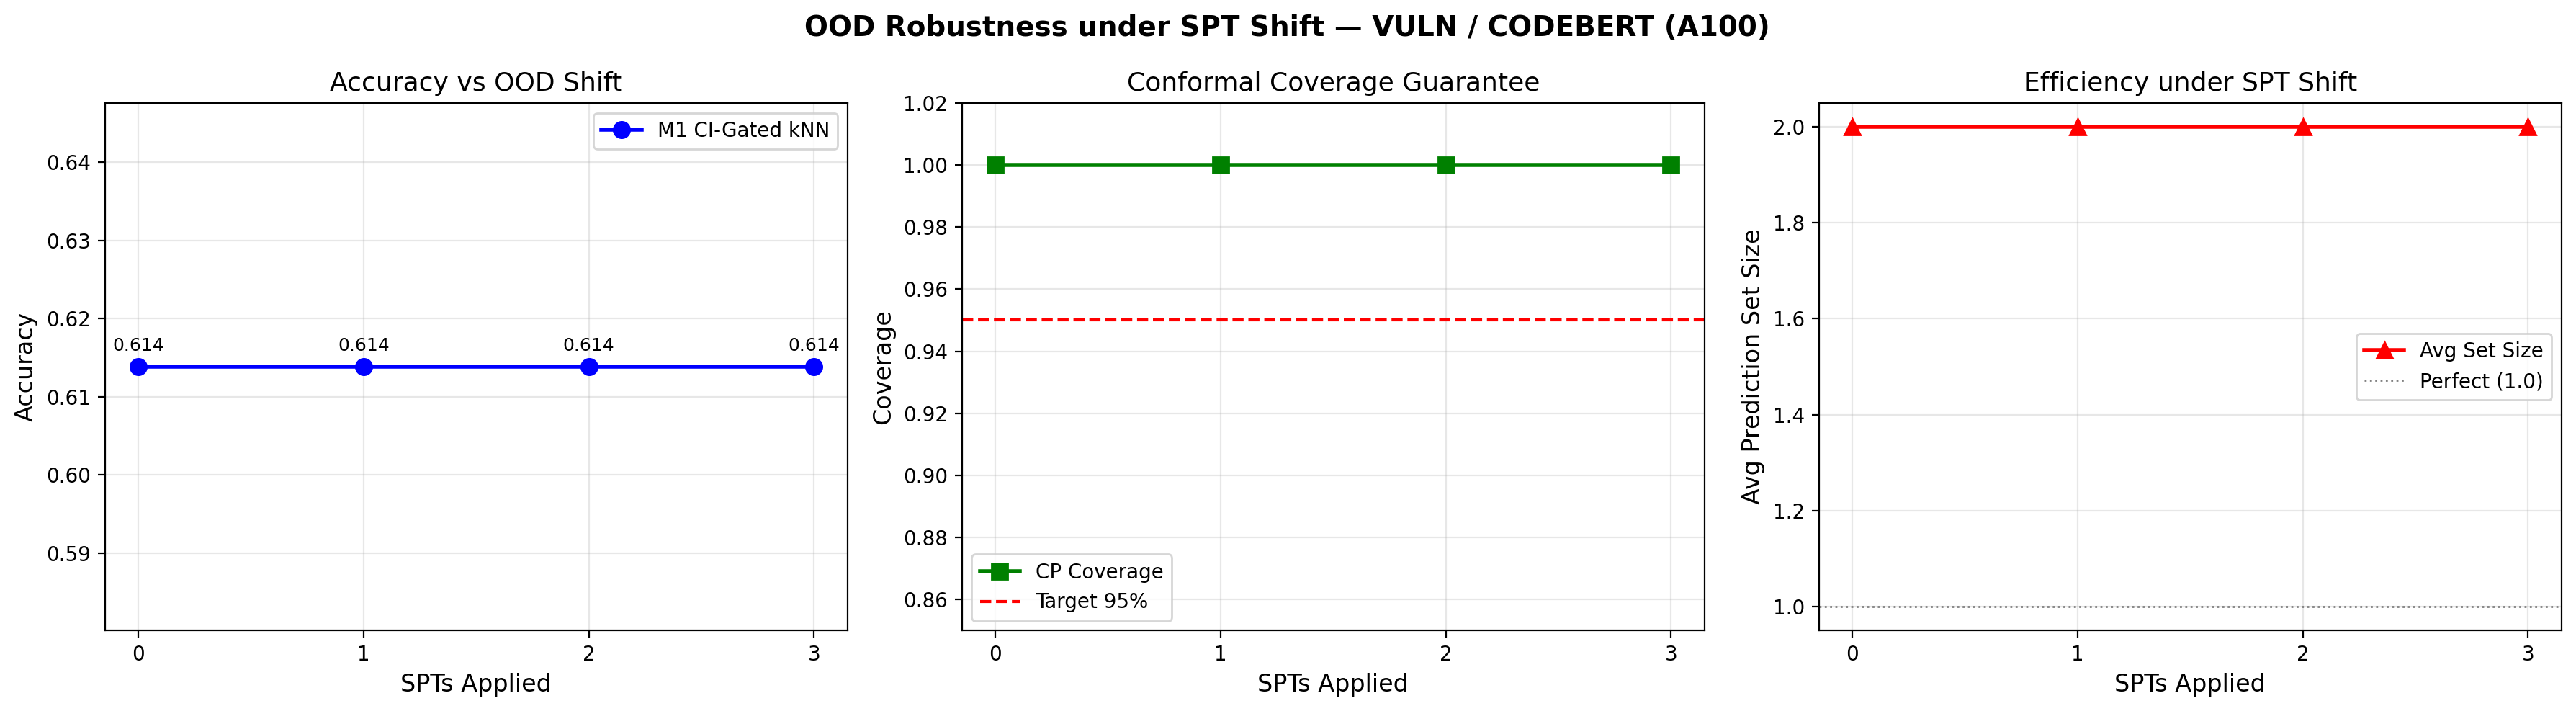

✅ Saved: /content/results_vuln_codebert/spt_degradation_curve.png


In [157]:
import matplotlib.pyplot as plt
matplotlib_inline = None
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('retina')  # crisp on A100 Colab
except ImportError:
    pass

n_levels = sorted(SPT_PATHS.keys())
m1_accs  = [accuracy_score(SPT_LABELS_DICT[n], SPT_PROBS_DICT[n].argmax(1)) for n in n_levels]
cp_covgs = [CP_SPT_METRICS[n]['marginal_coverage'] for n in n_levels]
cp_sizes = [CP_SPT_METRICS[n]['avg_set_size'] for n in n_levels]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'OOD Robustness under SPT Shift \u2014 {TASK.upper()} / {MODEL.upper()} (A100)',
             fontsize=14, fontweight='bold')

axes[0].plot(n_levels, m1_accs, 'b-o', lw=2, ms=8, label='M1 CI-Gated kNN')
axes[0].set_xlabel('SPTs Applied', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs OOD Shift', fontsize=13)
axes[0].set_xticks(n_levels)
axes[0].grid(True, alpha=0.3)
axes[0].legend()
for x, y in zip(n_levels, m1_accs):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

target = 1 - CFG['cp_alpha']
axes[1].plot(n_levels, cp_covgs, 'g-s', lw=2, ms=8, label='CP Coverage')
axes[1].axhline(target, color='red', ls='--', lw=1.5, label=f'Target {target*100:.0f}%')
axes[1].set_xlabel('SPTs Applied', fontsize=12)
axes[1].set_ylabel('Coverage', fontsize=12)
axes[1].set_title('Conformal Coverage Guarantee', fontsize=13)
axes[1].set_ylim(0.85, 1.02)
axes[1].set_xticks(n_levels)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(n_levels, cp_sizes, 'r-^', lw=2, ms=8, label='Avg Set Size')
axes[2].axhline(1.0, color='gray', ls=':', lw=1, label='Perfect (1.0)')
axes[2].set_xlabel('SPTs Applied', fontsize=12)
axes[2].set_ylabel('Avg Prediction Set Size', fontsize=12)
axes[2].set_title('Efficiency under SPT Shift', fontsize=13)
axes[2].set_xticks(n_levels)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plot_path = f"{CFG['output_dir']}/spt_degradation_curve.png"
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'\u2705 Saved: {plot_path}')

## 📊 Phase 7 — McNemar Statistical Significance Tests

In [158]:
from supcon_finetune import run_significance_tests

ALL_PREDS = {
    'B1_model_only': MODEL_PROBS.argmax(1),
    'B3_calibrated': CAL_PROBS.argmax(1),
    'B4_knn':        B4_PREDS,
    'B5_protoknn':   PROTO_PREDS,
    'M1_gated_knn':  M1_PREDS,
}

SIG_RESULTS = run_significance_tests(
    all_preds    = ALL_PREDS,
    true_labels  = TRUE_LABELS,
    baseline_key = 'B1_model_only',
    output_dir   = f"{CFG['output_dir']}/significance",
)


McNemar's Significance Tests (baseline: B1_model_only)

[McNemar] B1_model_only vs B3_calibrated
  A right/B wrong: 1,  A wrong/B right: 8
  chi2 = 4.0000, p-value = 0.045500
  ✅ Significant (p<0.05): B3_calibrated is better

[McNemar] B1_model_only vs B4_knn
  A right/B wrong: 563,  A wrong/B right: 1063
  chi2 = 153.1371, p-value = 0.000000
  ✅ Significant (p<0.05): B4_knn is better

[McNemar] B1_model_only vs B5_protoknn
  A right/B wrong: 810,  A wrong/B right: 1321
  chi2 = 122.0554, p-value = 0.000000
  ✅ Significant (p<0.05): B5_protoknn is better

[McNemar] B1_model_only vs M1_gated_knn
  A right/B wrong: 563,  A wrong/B right: 1063
  chi2 = 153.1371, p-value = 0.000000
  ✅ Significant (p<0.05): M1_gated_knn is better

McNemar results saved to /content/results_vuln_codebert/significance/mcnemar_results.json


## 📋 Phase 8 — Final Comparison Table + Plots

In [159]:
def row(name, probs, preds, labels):
    return {
        'Method': name,
        'Acc':   accuracy_score(labels, preds),
        'F1-M':  f1_score(labels, preds, average='macro', zero_division=0),
        'MCC':   matthews_corrcoef(labels, preds),
        'ECE':   compute_ece(probs, labels)[0],
        'Brier': compute_brier_score(probs, labels, CFG['num_classes']),
    }

lit = ([{'Method':'CodeBERT (Lu et al. 2021)',      'Acc':0.613,'F1-M':'--','MCC':'--','ECE':'--','Brier':'--'},
        {'Method':'GraphCodeBERT (Guo et al. 2021)','Acc':0.715,'F1-M':'--','MCC':'--','ECE':'--','Brier':'--'}]
       if TASK == 'defect' else
       [{'Method':'CodeBERT (Lu et al. 2021)',   'Acc':'--','F1-M':0.628,'MCC':'--','ECE':'--','Brier':'--'},
        {'Method':'kNN-for-Vuln (EMNLP 2022)',   'Acc':'--','F1-M':0.660,'MCC':'--','ECE':'--','Brier':'--'}])

ROWS = lit + [
    row('B1: Model-Only',          MODEL_PROBS,  MODEL_PROBS.argmax(1), TRUE_LABELS),
    row('B3: + Temp Scaling',      CAL_PROBS,    CAL_PROBS.argmax(1),   TRUE_LABELS),
    row('B4: + kNN (always-on)',    B4_PROBS,     B4_PREDS,              TRUE_LABELS),
    row('B5: + ProtokNN',          PROTO_PROBS,  PROTO_PREDS,            TRUE_LABELS),
    row('M1: CI-Gated kNN [OURS]', M1_PROBS,     M1_PREDS,               TRUE_LABELS),
]

def fmt(v): return f'{v:.4f}' if isinstance(v, float) else str(v)

print('\n' + '='*88)
print(f'FINAL COMPARISON — {TASK.upper()} / {MODEL.upper()} / A100')
print('='*88)
print(f'{"Method":<38} {"Acc":>8} {"F1-M":>8} {"MCC":>8} {"ECE":>8} {"Brier":>8}')
print('-'*88)
for r in ROWS:
    print(f'{r["Method"]:<38} {fmt(r["Acc"]):>8} {fmt(r["F1-M"]):>8} '
          f'{fmt(r["MCC"]):>8} {fmt(r["ECE"]):>8} {fmt(r["Brier"]):>8}')
print('='*88)

with open(f"{CFG['output_dir']}/final_table_{TASK}_{MODEL}.json", 'w') as f:
    json.dump(ROWS, f, indent=2, default=str)
print('\n\u2705 Table saved')


FINAL COMPARISON — VULN / CODEBERT / A100
Method                                      Acc     F1-M      MCC      ECE    Brier
----------------------------------------------------------------------------------------
CodeBERT (Lu et al. 2021)                    --   0.6280       --       --       --
kNN-for-Vuln (EMNLP 2022)                    --   0.6600       --       --       --
B1: Model-Only                           0.4308   0.3485  -0.2447   0.1001   0.5160
B3: + Temp Scaling                       0.4334   0.3497  -0.2405   0.0666   0.5000
B4: + kNN (always-on)                    0.6138   0.6072   0.2174   0.1044   0.4616
B5: + ProtokNN                           0.6179   0.6167   0.2568   0.0402   0.4488
M1: CI-Gated kNN [OURS]                  0.6138   0.6072   0.2174   0.0466   0.4436

✅ Table saved


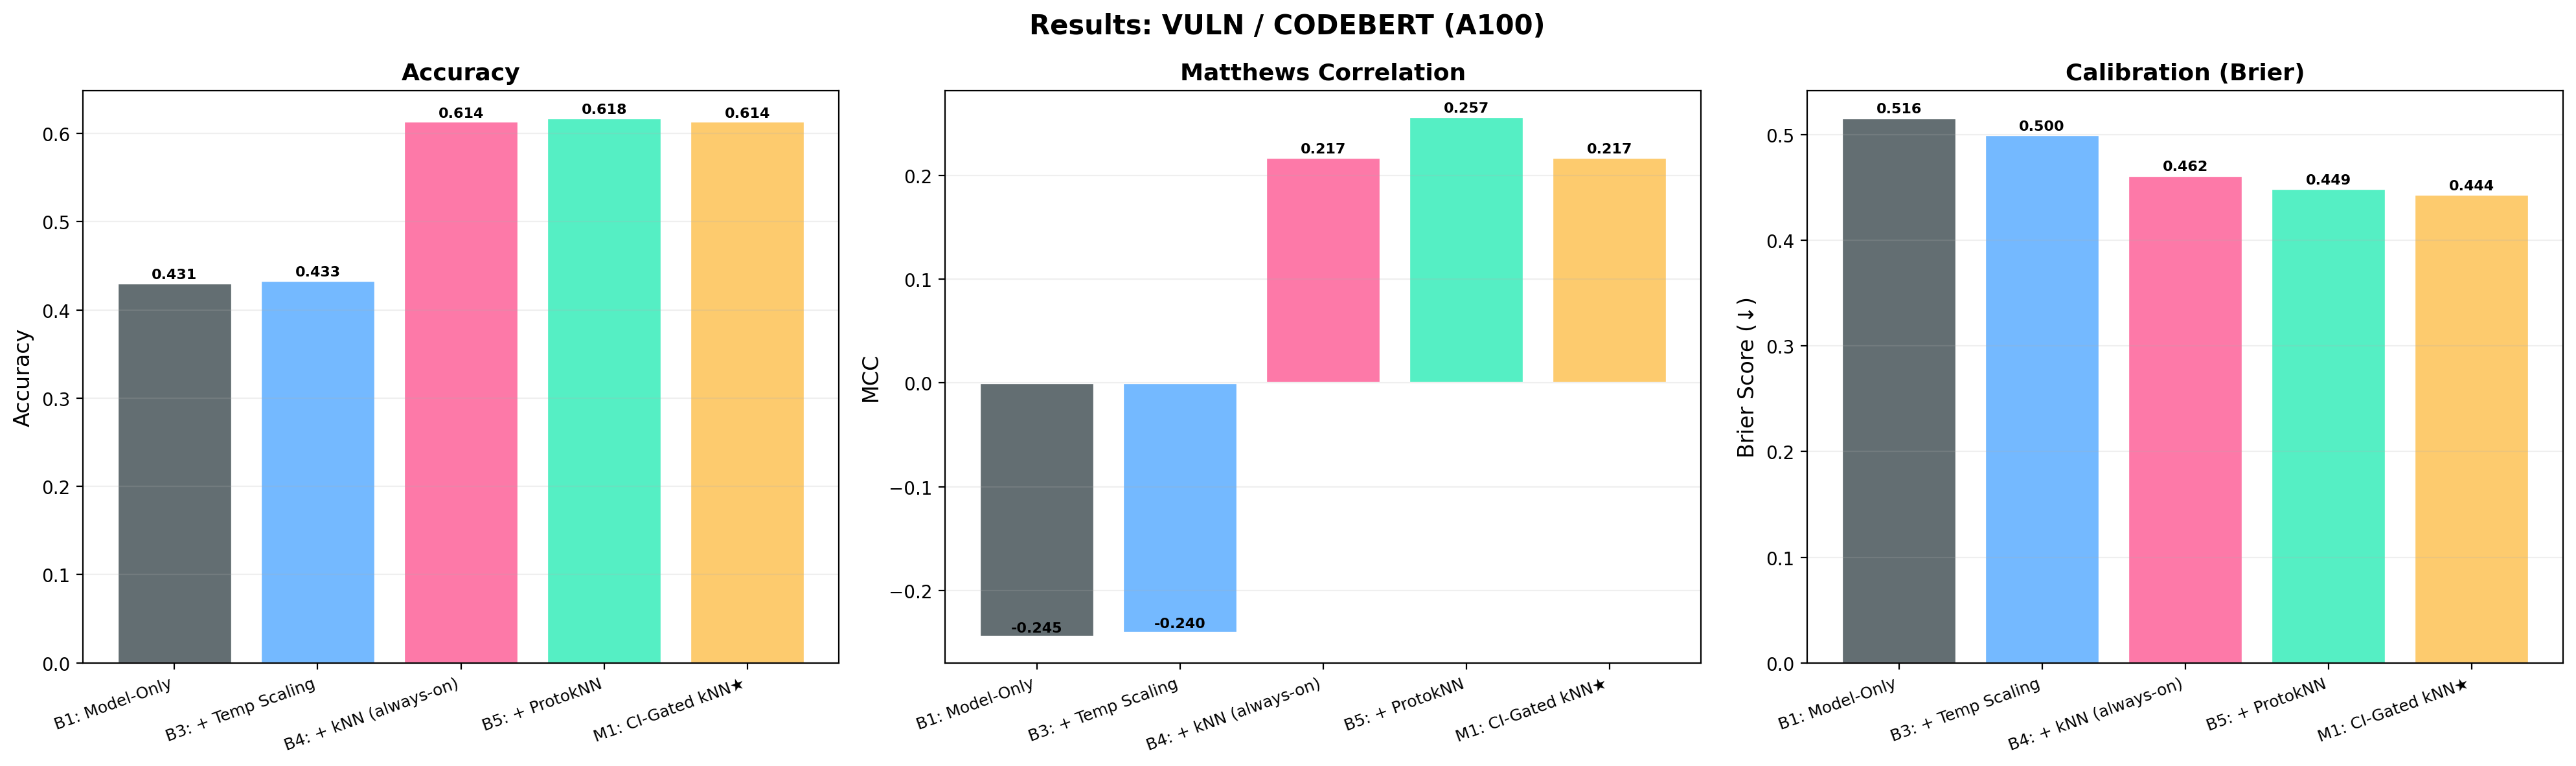

✅ Saved comparison_bars.png


In [160]:
import matplotlib.pyplot as plt, numpy as np

# Filter out rows where 'MCC' is not a float, which excludes the literature values with '--'
our_rows = [r for r in ROWS if isinstance(r['MCC'], float)]
names    = [r['Method'].replace(' [OURS]', '★') for r in our_rows]
COLS = ['#636e72','#74b9ff','#fd79a8','#55efc4','#fdcb6e']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Results: {TASK.upper()} / {MODEL.upper()} (A100)', fontsize=15, fontweight='bold')

for ax, key, ylabel, title in zip(
    axes,
    ['Acc', 'MCC', 'Brier'],
    ['Accuracy', 'MCC', 'Brier Score (↓)'],
    ['Accuracy', 'Matthews Correlation', 'Calibration (Brier)'],
):
    vals = [r[key] for r in our_rows]
    x    = np.arange(len(names))
    bars = ax.bar(x, vals, color=COLS[:len(names)], edgecolor='white', lw=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/comparison_bars.png", dpi=200, bbox_inches='tight')
plt.show()
print('\u2705 Saved comparison_bars.png')


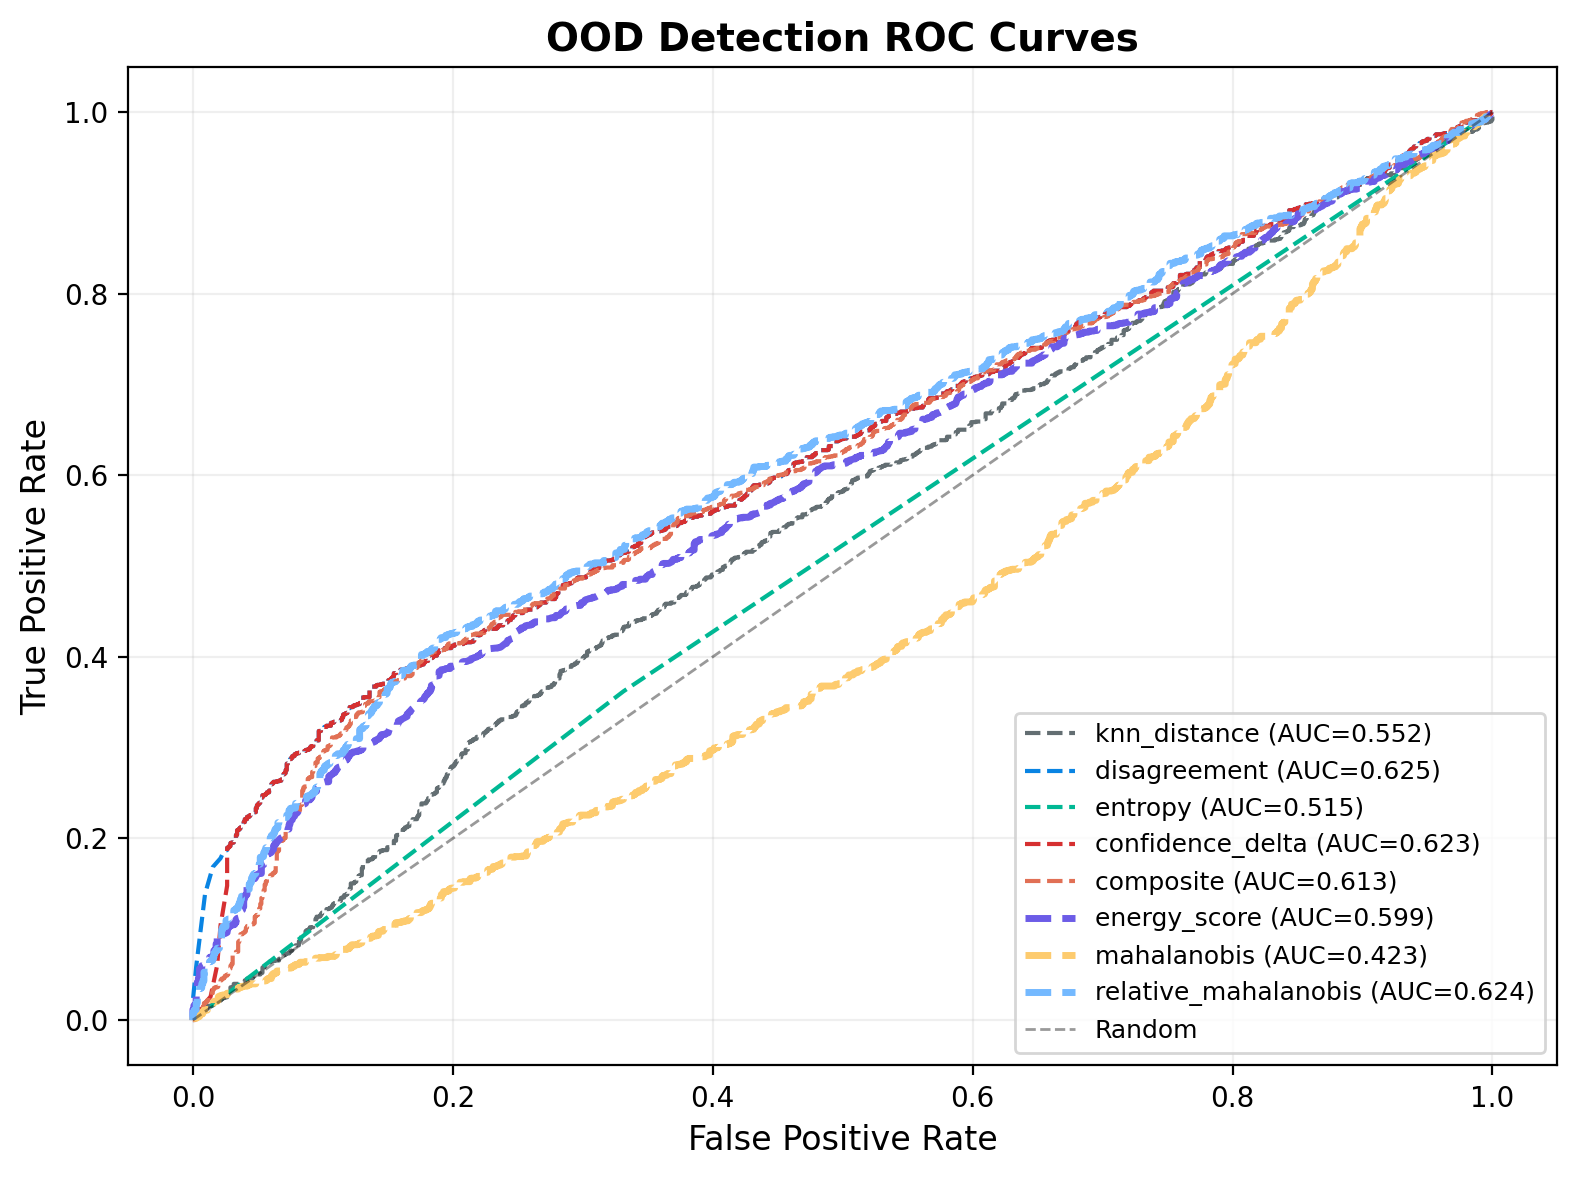

✅ Saved ood_roc_curves.png


In [161]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
PAL = ['#636e72','#0984e3','#00b894','#d63031','#e17055','#6c5ce7','#fdcb6e','#74b9ff']
for (name, r), color in zip(OOD_RESULTS.items(), PAL):
    lw = 2.5 if any(x in name for x in ['mahalanobis','energy']) else 1.5
    ls = '-' if r['auc'] > 0.75 else '--'
    ax.plot(r['roc_fpr'], r['roc_tpr'], lw=lw, ls=ls, color=color,
            label=f'{name} (AUC={r["auc"]:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('OOD Detection ROC Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/ood_roc_curves.png", dpi=200, bbox_inches='tight')
plt.show()
print('\u2705 Saved ood_roc_curves.png')

## 📥 Phase 9 — Zip & Download Results

In [ ]:
import shutil
from google.colab import files

zip_base = f'/content/CI_kNN_{TASK}_{MODEL}_results'
shutil.make_archive(zip_base, 'zip', CFG['output_dir'])
size_mb = os.path.getsize(f'{zip_base}.zip') / 1e6
print(f'✅ Zipped: {zip_base}.zip  ({size_mb:.1f} MB)')

# Also save to Drive so you don't lose results if session resets
DRIVE_ROOT   = f"/content/drive/MyDrive/CI_kNN_Models"
SAVE_TAG     = f"{TASK}_{MODEL}"
drive_zip    = f"{DRIVE_ROOT}/{SAVE_TAG}/results_{TASK}_{MODEL}.zip"
os.makedirs(f"{DRIVE_ROOT}/{SAVE_TAG}", exist_ok=True)
shutil.copy2(f'{zip_base}.zip', drive_zip)
print(f'✅ Results also backed up to Drive: {drive_zip}')

files.download(f'{zip_base}.zip')


---
## 🔄 2×2 Experiment Matrix — Run Instructions

| Run | `TASK` | `MODEL` | A100 Time |
|:----|:-------|:--------|----------:|
| 1 | `'defect'` | `'codebert'` | ~2h |
| 2 | `'defect'` | `'graphcodebert'` | ~2h |
| 3 | `'vuln'` | `'codebert'` | ~2.5h |
| 4 | `'vuln'` | `'graphcodebert'` | ~2.5h |

Change `TASK` and `MODEL` in the config cell and **Runtime → Restart & Run All**.

### Vulnerability Detection (`TASK='vuln'`)
```python
# Unzip Devign dataset first:
!cd {DRIVE_REPO}/Vulnerability-Detection && unzip dataset.zip
# If CodeDataset fails, the Devign field is 'func' not 'input':
# Edit knn_datastore.py line: code = js.get('func', js.get('input', ''))
```

### [OPTIONAL] SupCon Fine-Tuning (run before Phase 3)
```python
from supcon_finetune import SupConTrainer
trainer = SupConTrainer(
    model=model, tokenizer=tokenizer, device=device,
    temperature=0.07, epochs=2, lr=1e-5,
    output_dir=f"{CFG['output_dir']}/supcon"
)
trainer.fit(train_dataset)  # then rebuild DATASTORE
```

### A100 vs T4 — What Changes Automatically
| Setting | A100 | T4 |
|:--------|:-----|:---|
| Train batch | 128 | 32 |
| Eval batch | 256 | 64 |
| bf16 autocast | Yes | No |
| FAISS GPU | Yes | No |
| num_workers | 4 | 2 |

---
## 💾 Drive Save/Load Workflow

| Step | Cell to Run | Notes |
|------|-------------|-------|
| 1st run (defect) | Phase 1 → Save-to-Drive cell | ~45 min A100 |
| 1st run (vuln)   | Phase 1 → Save-to-Drive cell | ~45 min A100 |
| Repeat run       | Load-from-Drive cell → skip to Phase 3 | ~2 min |

**Drive structure created automatically:**
```
MyDrive/CI_kNN_Models/
  defect_codebert/
    model.bin             ← ~490 MB
    datastore/            ← FAISS index
    temperature.npy       ← calibration scalar
    results_defect_codebert.zip
  vuln_graphcodebert/
    model.bin
    ...
```
